In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 

In [3]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
data['eta'] = - data['eta']  # Negate eta to match model convention
display(data)

,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,0.140783,0,-0.005763,-0.000471,0.996944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415552,15.9,1.4,2404.0,2.588773,6.969502,0.494206,-2.285347,3.283184,0.694411,247,-0.020117,-0.000300,0.064722
415553,15.9,1.4,2405.0,2.568657,6.969502,0.493907,-2.285347,3.281990,0.713334,247,-0.020923,-0.000300,0.064333
415554,15.9,1.4,2406.0,2.547734,6.969502,0.493607,-2.285347,3.280796,0.733063,247,-0.021729,-0.000300,0.063944
415555,15.9,1.4,2407.0,2.526005,6.969502,0.493307,-2.285347,3.279602,0.753597,247,-0.021729,-0.000300,0.063556


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [4]:
# Batch data
feature_cols = ['I', 'u', 'soc', 'Ue']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([248, 7049, 4])  (padded, use mask for loss)
mask      : torch.Size([248, 7049])


In [5]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//4, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//4, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


# Build Model

In [6]:
def R0_func(u, I):
    ''' 
    Finds the R0 value for given u and I 
    Adjusts voltage curve 
    '''
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

In [ ]:
"""
Battery Neural ODE – Voltage prediction (V only, discharge)
=============================================================

Physics (ECM-inspired decomposition):
    dSOC/dt  = −I / Q0                        (known, constant I)
    dU1/dt   = NN(U1, SOC, I, u; θ)           (learned)
    V        = Ue(SOC) − I·R0(I, u) − U1      (algebraic output)

States  z = [SOC, U1]
Inputs  (constant per trajectory): I, u

Mirrors the Brucker et al. (2022) grey-box approach but simplified:
instead of learning R1(SOC, I) inside the RC equation, we let a
small network directly output dU1/dt.

Usage
-----
Paste after your data-loading cell.  Requires:
    data      – DataFrame with columns [I, u, soc, Ue, V, F, eta, trajectory, t]
    Q0        – total charge capacity in As  (e.g. 17921.57581)
    R0_func   – known R0(u, I)
    DT        – time step (1 s)
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


# ╔══════════════════════════════════════════════════════════╗
# ║  1. KNOWN PHYSICS                                       ║
# ╚══════════════════════════════════════════════════════════╝

class UeLookup:
    """
    Ue(SOC) via linear interpolation from data.

    Uses scipy (non-differentiable w.r.t. SOC).  This is fine because
    dSOC/dt has no learnable parameters, so no gradient needs to flow
    through Ue back to NN weights.

    ► If you later make Q0 learnable, replace this with a torch spline
      or a small fitted network so gradients can propagate.
    """
    def __init__(self, soc_arr, ue_arr):
        idx = np.argsort(soc_arr)
        self._f = interp1d(soc_arr[idx], ue_arr[idx],
                           kind='linear', fill_value='extrapolate')

    def __call__(self, soc):
        ue = self._f(soc.detach().cpu().numpy())
        return torch.tensor(ue, dtype=soc.dtype, device=soc.device)


# ╔══════════════════════════════════════════════════════════╗
# ║  2. NEURAL NETWORK  dU1/dt = NN(U1, SOC, I, u)          ║
# ╚══════════════════════════════════════════════════════════╝

class U1Net(nn.Module):
    """
    Small feedforward network:  (U1, SOC, I, u) → dU1/dt

    Design choices
    ──────────────
    • Tanh activation  → C∞ vector field → smooth ODE trajectories.
      (ReLU works too but gives a piecewise-linear field; less smooth.)
    • Small-weight init → dU1/dt ≈ 0 at epoch 0, so the model starts
      at V ≈ Ue − I·R0  (the static ECM) and gradually learns the
      dynamic correction.

    ► To add depth later:  insert more (Linear + Tanh) pairs.
    ► To add force channel: widen the output to 2 and return [dU1, dU2]
      where U2 feeds into a force algebraic equation.
    """
    def __init__(self, n_hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1),
        )
        # Start near zero so initial prediction ≈ static ECM
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=0.1)
                nn.init.zeros_(m.bias)

    def forward(self, U1, SOC, I, u):
        """All inputs: (B, 1) → output: (B, 1)"""
        x = torch.cat([U1, SOC, I, u], dim=-1)
        return self.net(x)


# ╔══════════════════════════════════════════════════════════╗
# ║  3. ODE RIGHT-HAND SIDE                                  ║
# ╚══════════════════════════════════════════════════════════╝

class BatteryODE(nn.Module):
    """
    dz/dt   for   z = [SOC, U1]

    Constant inputs I, u are set once per trajectory via .set_inputs()
    before calling the integrator — same pattern as Brucker's func0.i.

    ► To add a force state later, extend z to [SOC, U1, U_F] and
      append a third row to dz/dt.
    """
    def __init__(self, u1_net, Q0):
        super().__init__()
        self.u1_net = u1_net
        self.Q0     = torch.tensor(Q0, dtype=torch.float32)
        self._I = None      # set per trajectory
        self._u = None

    def set_inputs(self, I, u):
        """Call before each integration. I, u: (B, 1)."""
        self._I = I
        self._u = u

    def forward(self, t, z):
        """
        t : scalar   (current time — required by odeint signature)
        z : (B, 2)   →  [SOC, U1]
        """
        SOC = z[:, 0:1]
        U1  = z[:, 1:2]

        # ── physics ──
        dSOC = -self._I / self.Q0

        # ── learned ──
        dU1 = self.u1_net(U1, SOC, self._I, self._u)

        return torch.cat([dSOC, dU1], dim=-1)      # (B, 2)


# ╔══════════════════════════════════════════════════════════╗
# ║  4. INTEGRATORS                                          ║
# ╚══════════════════════════════════════════════════════════╝

def euler_integrate(func, z0, t_eval, **_ignored):
    """
    Forward Euler.  Same call signature as torchdiffeq.odeint,
    so you can swap freely:

        z = euler_integrate(ode, z0, t)   # simple, transparent
        z = odeint(ode, z0, t)            # adaptive, accurate

    ► For higher order: copy this and add an RK4 stage.
    """
    zs = [z0]
    z  = z0
    for i in range(len(t_eval) - 1):
        dt = t_eval[i + 1] - t_eval[i]
        z  = z + dt * func(t_eval[i], z)
        zs.append(z)
    return torch.stack(zs)          # (T, B, 2)


def rk4_integrate(func, z0, t_eval, **_ignored):
    """Classical RK4.  Same signature as above."""
    zs = [z0]
    z  = z0
    for i in range(len(t_eval) - 1):
        dt = t_eval[i + 1] - t_eval[i]
        ti = t_eval[i]
        k1 = func(ti,          z)
        k2 = func(ti + dt/2,   z + dt/2 * k1)
        k3 = func(ti + dt/2,   z + dt/2 * k2)
        k4 = func(ti + dt,     z + dt   * k3)
        z  = z + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
        zs.append(z)
    return torch.stack(zs)


# ╔══════════════════════════════════════════════════════════╗
# ║  5. FULL MODEL: INTEGRATE + ALGEBRAIC OUTPUT             ║
# ╚══════════════════════════════════════════════════════════╝

class BatteryModel(nn.Module):
    """
    Wires together:  ODE integration  →  algebraic output V.

    Parameters
    ----------
    ode_func   : BatteryODE instance
    Ue_lookup  : UeLookup instance
    R0_func    : callable(u, I) → R0
    integrator : 'euler' | 'rk4' | any torchdiffeq method string ('dopri5', …)
    """
    def __init__(self, ode_func, Ue_lookup, R0_func, integrator='dopri5'):
        super().__init__()
        self.ode        = ode_func
        self.Ue         = Ue_lookup
        self.R0         = R0_func
        self.integrator = integrator

    def forward(self, I, u, soc0, t_eval):
        """
        I, u, soc0 : (B, 1)   — constant per trajectory
        t_eval     : (T,)     — time grid (shared, padded to longest)

        Returns
        -------
        V_pred  : (B, T)
        SOC_pred: (B, T)
        U1_pred : (B, T)
        """
        B = I.shape[0]
        self.ode.set_inputs(I, u)

        # Initial state:  [SOC₀,  U1₀ = 0]
        z0 = torch.cat([soc0, torch.zeros(B, 1, dtype=torch.float32)], dim=-1)     # (B, 2)

        # ── Integrate ──
        if self.integrator == 'euler':
            z = euler_integrate(self.ode, z0, t_eval)
        elif self.integrator == 'rk4':
            z = rk4_integrate(self.ode, z0, t_eval)
        else:
            from torchdiffeq import odeint
            z = odeint(self.ode, z0, t_eval,
                       method=self.integrator, rtol=1e-5, atol=1e-7)

        SOC = z[:, :, 0]                                       # (T, B)
        U1  = z[:, :, 1]

        # ── Algebraic output ──
        Ue = self.Ue(SOC)                                       # (T, B)
        R0 = self.R0(u.squeeze(-1), I.squeeze(-1))              # (B,)
        V  = Ue - I.squeeze(-1) * R0 - U1                       # (T, B)

        return V.T, SOC.T, U1.T                                 # all (B, T)


# ╔══════════════════════════════════════════════════════════╗
# ║  6. DATA EXTRACTION  (from your DataFrame)               ║
# ╚══════════════════════════════════════════════════════════╝

def prepare_trajectories(data):
    """
    Convert the DataFrame into a list of per-trajectory dicts,
    each containing the tensors needed for training.

    Returns
    -------
    trajs : list of dict with keys
        'I', 'u', 'soc0'  : (1, 1) tensors
        't'                : (T_i,) tensor
        'V', 'eta'         : (T_i,) tensors   (targets)
    """
    trajs = []
    for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        trajs.append(dict(
            I    = torch.tensor([[grp['I'].iloc[0]]], dtype=torch.float32),
            u    = torch.tensor([[grp['u'].iloc[0]]], dtype=torch.float32),
            soc0 = torch.tensor([[grp['soc'].iloc[0]]], dtype=torch.float32),
            t    = torch.arange(len(grp), dtype=torch.float32),
            V    = torch.tensor(grp['V'].values, dtype=torch.float32),
            eta  = torch.tensor(grp['eta'].values, dtype=torch.float32),
        ))
    return trajs


# ╔══════════════════════════════════════════════════════════╗
# ║  7. TRAINING LOOP                                        ║
# ╚══════════════════════════════════════════════════════════╝

def train(model, train_trajs, test_trajs,
          n_epochs=300, lr=1e-3, print_every=20):
    """
    Train loop iterating over individual trajectories (à la Brucker).

    Each trajectory is a separate forward pass through the ODE solver,
    since they have different lengths and different constant inputs.
    Gradients accumulate over all training trajectories before a step
    (full-batch per epoch).

    ► For stochastic updates (like Brucker), move optimizer.step()
      inside the inner loop.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=50, factor=0.5
    )

    history = {'train': [], 'test': []}

    for epoch in range(1, n_epochs + 1):
        # ── Train ──
        model.train()
        optimizer.zero_grad()

        train_loss = 0.0
        order = np.random.permutation(len(train_trajs))

        for idx in order:
            tr = train_trajs[idx]
            V_pred, _, _ = model(tr['I'], tr['u'], tr['soc0'], tr['t'])
            loss = torch.mean((V_pred.squeeze(0) - tr['V']) ** 2)
            loss.backward()                     # accumulate gradients
            train_loss += loss.item()

        optimizer.step()                         # one step per epoch
        train_loss /= len(train_trajs)
        history['train'].append(train_loss)

        # # ── Test ──
        # model.eval()
        # test_loss = 0.0
        # with torch.no_grad():
        #     for tr in test_trajs:
        #         V_pred, _, _ = model(tr['I'], tr['u'], tr['soc0'], tr['t'])
        #         loss = torch.mean((V_pred.squeeze(0) - tr['V']) ** 2)
        #         test_loss += loss.item()
        # test_loss /= max(len(test_trajs), 1)
        # history['test'].append(test_loss)
        test_loss = 0

        scheduler.step(train_loss)

        if epoch % print_every == 0 or epoch == 1:
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:4d} | train MSE {train_loss:.6f} "
                  f"| test MSE {test_loss:.6f} | lr {cur_lr:.1e}")

    return history


# ╔══════════════════════════════════════════════════════════╗
# ║  8. PLOTTING                                             ║
# ╚══════════════════════════════════════════════════════════╝

def plot_predictions(model, trajs, title_prefix=''):
    """Plot V(t) predictions vs data for a list of trajectories."""
    n = len(trajs)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 7), squeeze=False)

    model.eval()
    with torch.no_grad():
        for j, tr in enumerate(trajs):
            V_pred, SOC_pred, U1_pred = model(
                tr['I'], tr['u'], tr['soc0'], tr['t']
            )
            t_np   = tr['t'].numpy()
            V_p    = V_pred.squeeze(0).numpy()
            V_d    = tr['V'].numpy()
            U1_np  = U1_pred.squeeze(0).numpy()
            SOC_np = SOC_pred.squeeze(0).numpy()

            I_val = tr['I'].item()
            u_val = tr['u'].item()

            # ── Voltage ──
            ax = axes[0, j]
            ax.plot(t_np, V_d, '--', label='data',    linewidth=1.5)
            ax.plot(t_np, V_p, '-',  label='NODE',    linewidth=1.5)
            ax.set_xlabel('t  [s]')
            ax.set_ylabel('V  [V]')
            ax.set_title(f'{title_prefix}I={I_val:.1f}, u={u_val:.3f}')
            ax.legend()

            # ── Learned U1 ──
            ax2 = axes[1, j]
            ax2.plot(t_np, U1_np, label='U1 (learned)')
            ax2.set_xlabel('t  [s]')
            ax2.set_ylabel('U1  [V]')
            ax2.legend()

    fig.tight_layout()
    return fig


def plot_history(history):
    """Plot training / test loss curves."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogy(history['train'], label='train')
    ax.semilogy(history['test'],  label='test')
    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    fig.tight_layout()
    return


In [12]:
# # ── Cell: imports ──
# from JN_node_test import (
#     UeLookup, U1Net, BatteryODE, BatteryModel,
#     prepare_trajectories, train, plot_predictions, plot_history
# )

# ╔══════════════════════════════════════════════════════════╗
# ║  Build Ue(SOC) lookup from your data                     ║
# ╚══════════════════════════════════════════════════════════╝

Ue_lookup = UeLookup(data['soc'].values, data['Ue'].values)

# Quick sanity check: Ue at SOC = 0.5
print(f"Ue(0.5) = {Ue_lookup(torch.tensor([0.5])).item():.4f} V")


# ╔══════════════════════════════════════════════════════════╗
# ║  Extract per-trajectory data                             ║
# ╚══════════════════════════════════════════════════════════╝

trajs = prepare_trajectories(data)
print(f"Total trajectories: {len(trajs)}")
for i, tr in enumerate(trajs[:3]):
    print(f"  traj {i}: I={tr['I'].item():.2f},  "
          f"u={tr['u'].item():.4f},  T={len(tr['t'])}")

# ── Train / test split ──
split = int(len(trajs) * 0.8)
train_trajs = trajs[:split]
test_trajs  = trajs[split:]
print(f"Train: {len(train_trajs)}  |  Test: {len(test_trajs)}")


# ╔══════════════════════════════════════════════════════════╗
# ║  Build the model                                         ║
# ╚══════════════════════════════════════════════════════════╝

Q0 = 17921.57581

u1_net   = U1Net(n_hidden=32)       # the learned part
ode_func = BatteryODE(u1_net, Q0)   # ODE right-hand side

model = BatteryModel(
    ode_func,
    Ue_lookup,
    R0_func,
    integrator='dopri5',    # start here; swap to 'dopri5' once it works
)

# Check parameter count
n_params = sum(p.numel() for p in model.parameters())
print(f"Learnable parameters: {n_params}")


# ╔══════════════════════════════════════════════════════════╗
# ║  Sanity check: forward pass before training              ║
# ╚══════════════════════════════════════════════════════════╝

# Pick one trajectory and check that V_pred ≈ Ue − I·R0
# (because U1 ≈ 0 at init thanks to small-weight initialisation)
tr0 = train_trajs[0]
with torch.no_grad():
    # print('type(tr0["I"]):', (tr0["I"]).dtype)
    # print(tr0['I'], tr0['u'], tr0['soc0'], tr0['t'])
    V_pred, SOC_pred, U1_pred = model(tr0['I'], tr0['u'], tr0['soc0'], tr0['t'])

print(f"\nBefore training (traj 0):")
print(f"  V_pred[0] = {V_pred[0, 0].item():.4f}   V_data[0] = {tr0['V'][0].item():.4f}")
print(f"  U1[0]     = {U1_pred[0, 0].item():.6f}   (should be ≈ 0)")
print(f"  V_pred[-1]= {V_pred[0, -1].item():.4f}   V_data[-1]= {tr0['V'][-1].item():.4f}")


# ╔══════════════════════════════════════════════════════════╗
# ║  Train                                                   ║
# ╚══════════════════════════════════════════════════════════╝

history = train(
    model,
    train_trajs,
    test_trajs,
    n_epochs=50,
    lr=1e-3,
    print_every=1,
)

Ue(0.5) = 3.7604 V
Total trajectories: 248
  traj 0: I=10.95,  u=-0.0575,  T=1476
  traj 1: I=19.42,  u=-2.9753,  T=758
  traj 2: I=2.99,  u=-0.1437,  T=5847
Train: 198  |  Test: 50
Learnable parameters: 193

Before training (traj 0):
  V_pred[0] = 4.2408   V_data[0] = 4.2398
  U1[0]     = 0.000000   (should be ≈ 0)
  V_pred[-1]= -12.5255   V_data[-1]= 2.3882
Epoch    1 | train MSE 253.842960 | test MSE 0.000000 | lr 1.0e-03
Epoch    2 | train MSE 132.857815 | test MSE 0.000000 | lr 1.0e-03
Epoch    3 | train MSE 63.940340 | test MSE 0.000000 | lr 1.0e-03
Epoch    4 | train MSE 26.271438 | test MSE 0.000000 | lr 1.0e-03
Epoch    5 | train MSE 7.785544 | test MSE 0.000000 | lr 1.0e-03
Epoch    6 | train MSE 1.170220 | test MSE 0.000000 | lr 1.0e-03
Epoch    7 | train MSE 1.587065 | test MSE 0.000000 | lr 1.0e-03
Epoch    8 | train MSE 5.543153 | test MSE 0.000000 | lr 1.0e-03
Epoch    9 | train MSE 10.460401 | test MSE 0.000000 | lr 1.0e-03
Epoch   10 | train MSE 14.639042 | test MSE 0.

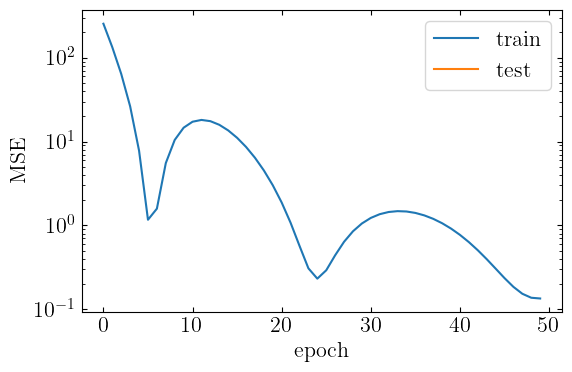

In [38]:
plot_history(history)

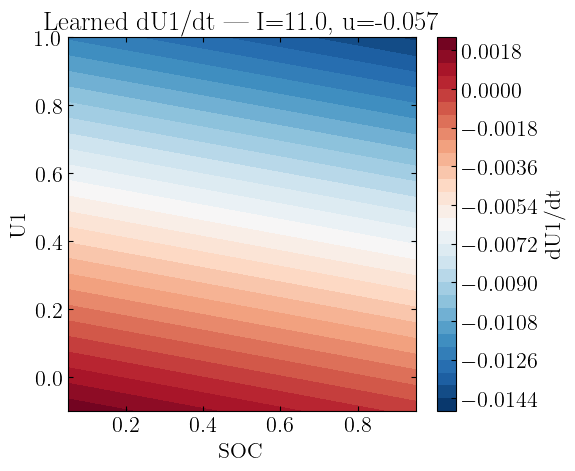

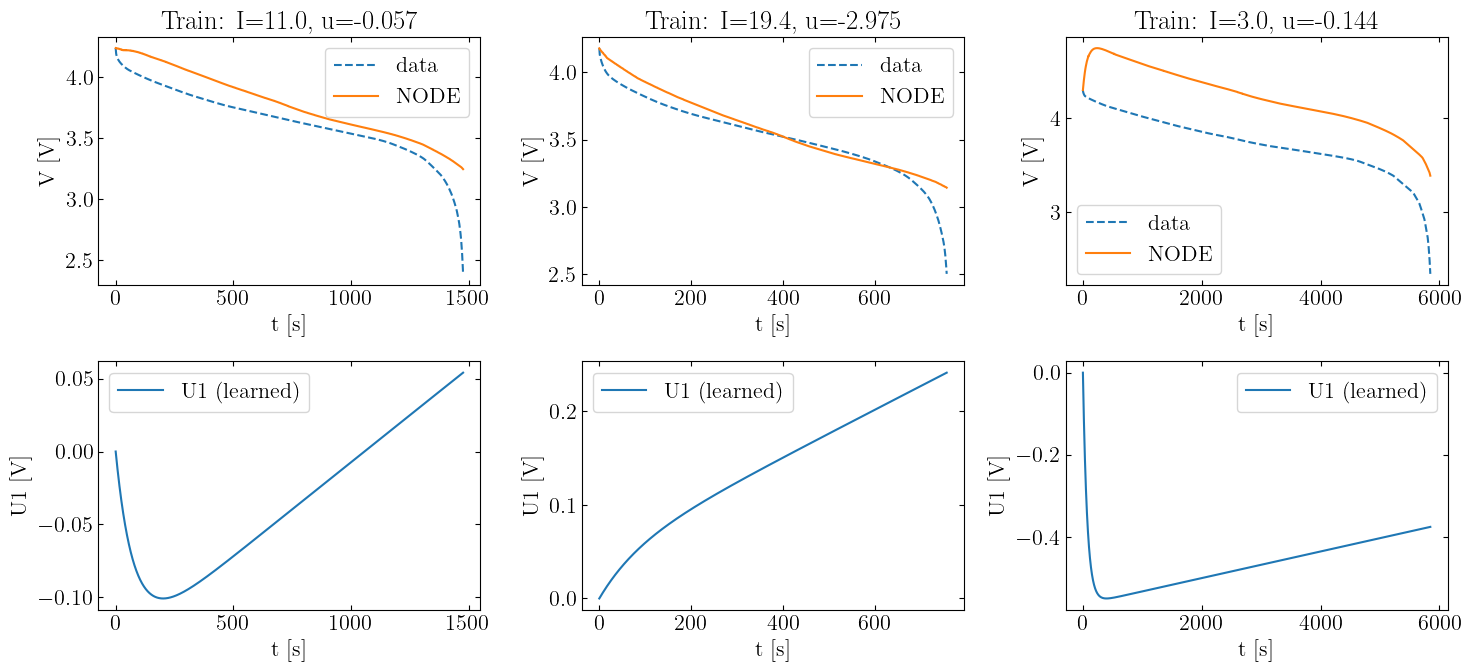

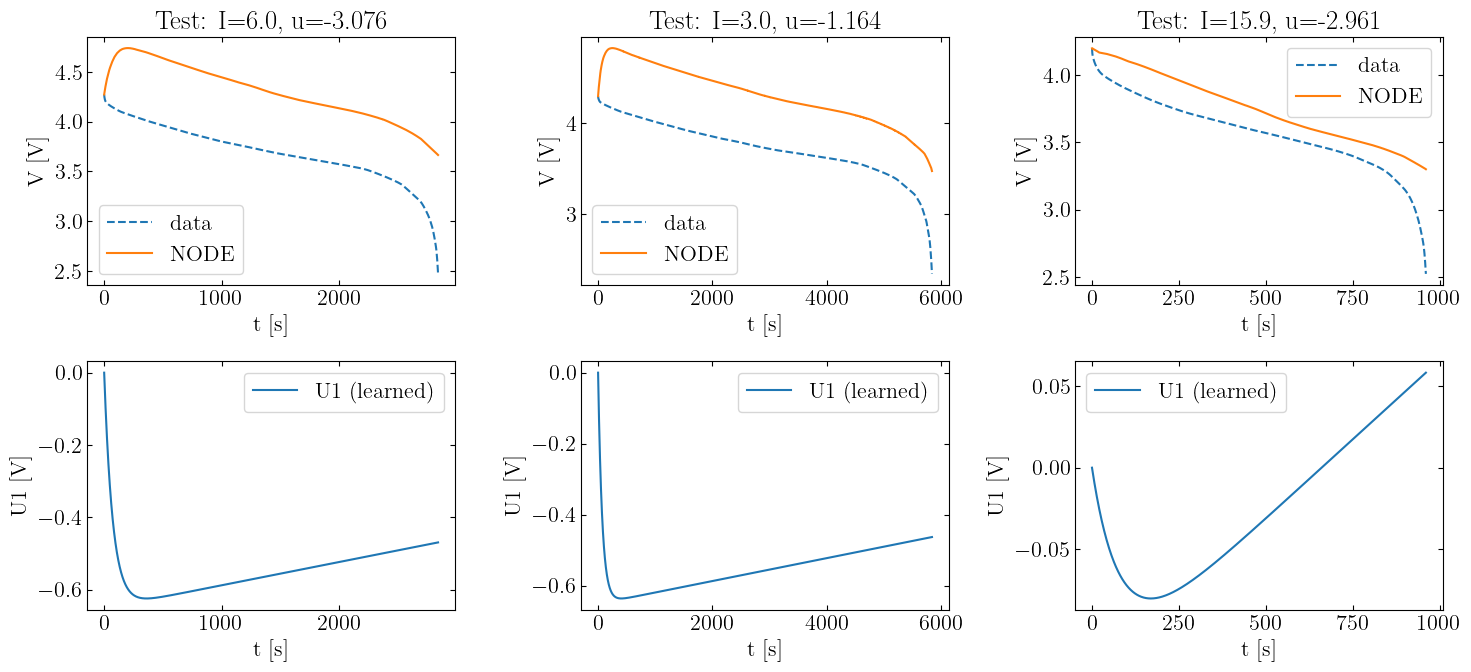

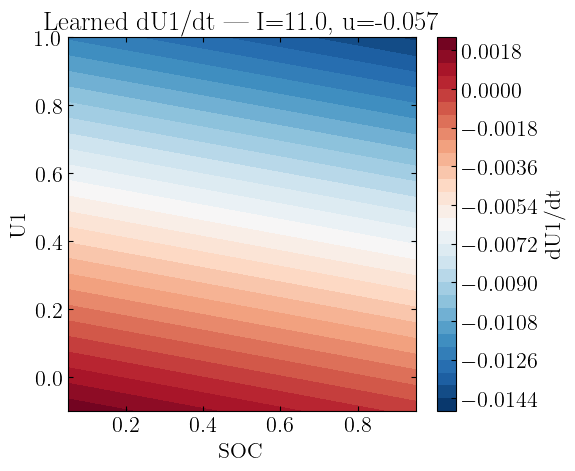

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  Evaluate                                                ║
# ╚══════════════════════════════════════════════════════════╝

# Plot a few training trajectories
fig_train = plot_predictions(model, train_trajs[:3], title_prefix='Train: ')

# Plot test trajectories
fig_test = plot_predictions(model, test_trajs[:3], title_prefix='Test: ')


# ╔══════════════════════════════════════════════════════════╗
# ║  Inspect the learned vector field (optional)             ║
# ╚══════════════════════════════════════════════════════════╝
# This helps you check whether dU1/dt has a sensible shape.
# For a fixed (I, u), sweep U1 and SOC and plot dU1/dt.

def plot_vector_field(model, I_val, u_val, n_grid=30):
    """Visualise dU1/dt as a function of (SOC, U1) at fixed I, u."""
    soc_grid = np.linspace(0.05, 0.95, n_grid)
    u1_grid  = np.linspace(-0.1, 1.0, n_grid)
    SOC_g, U1_g = np.meshgrid(soc_grid, u1_grid)

    SOC_t = torch.tensor(SOC_g.ravel(), dtype=torch.float32).unsqueeze(-1)
    U1_t  = torch.tensor(U1_g.ravel(),  dtype=torch.float32).unsqueeze(-1)
    I_t   = torch.full_like(SOC_t, I_val)
    u_t   = torch.full_like(SOC_t, u_val)

    with torch.no_grad():
        dU1 = model.ode.u1_net(U1_t, SOC_t, I_t, u_t).numpy().reshape(n_grid, n_grid)

    fig, ax = plt.subplots(figsize=(6, 5))
    c = ax.contourf(SOC_g, U1_g, dU1, levels=30, cmap='RdBu_r')
    fig.colorbar(c, ax=ax, label='dU1/dt')
    ax.set_xlabel('SOC')
    ax.set_ylabel('U1')
    ax.set_title(f'Learned dU1/dt  |  I={I_val:.1f}, u={u_val:.3f}')
    fig.tight_layout()
    return fig


# Example: plot for the first training trajectory's (I, u)
plot_vector_field(model,
                  I_val=train_trajs[0]['I'].item(),
                  u_val=train_trajs[0]['u'].item())


In [ ]:
"""
Two-stage training for Battery NODE
====================================

Stage 1 (collocation):  Train NN on pointwise dU1/dt targets.
                        Fast, no ODE solve, stable from epoch 1.

Stage 2 (shooting):     Fine-tune through the ODE solver.
                        Enforces trajectory consistency.

This mirrors Brucker's strategy of static pre-training followed
by dynamic training — but adapted to your formulation.

Paste after your data-loading cell and battery_node.py import.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from JN_node_test import (
    UeLookup, U1Net, BatteryODE, BatteryModel,
    prepare_trajectories, train, plot_predictions, plot_history,
)

# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 0: PREPARE COLLOCATION TARGETS                   ║
# ╚══════════════════════════════════════════════════════════╝

def build_collocation_data(data, Q0, R0_func):
    """
    From the DataFrame, compute the pointwise targets for dU1/dt.

    Physics:
        V     = Ue(SOC) − I·R0 − U1
        dV/dt = dUe/dSOC · dSOC/dt  −  dU1/dt      (I·R0 is constant)

    Rearranging:
        dU1/dt = dUe/dSOC · (−I/Q0)  −  dV/dt

    We also reconstruct U1(t) by cumulative integration of the data's
    dV column, so the NN sees the right input during collocation.

    Returns
    -------
    inputs  : (N, 4)  →  [U1, SOC, I, u]
    targets : (N, 1)  →  dU1/dt
    """
    all_inputs  = []
    all_targets = []

    for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)

        I_val   = grp['I'].values[0]
        u_val   = grp['u'].values[0]
        soc     = grp['soc'].values
        Ue      = grp['Ue'].values
        V       = grp['V'].values
        dV      = grp['dV'].values        # dV/dt from data

        # ── dUe/dSOC via finite differences on the Ue(SOC) curve ──
        # (safer than differentiating the interpolant analytically)
        dUe_dSOC = np.gradient(Ue, soc)

        # ── dU1/dt target ──
        dSOC_dt  = -I_val / Q0
        dU1_dt   = dUe_dSOC * dSOC_dt - dV

        # ── U1(t) by reconstruction ──
        # V = Ue - I*R0 - U1  →  U1 = Ue - I*R0 - V
        R0_val = R0_func(u_val, I_val)
        U1_vals = Ue - I_val * R0_val - V

        # ── Assemble ──
        N = len(grp)
        inp = np.stack([U1_vals,
                        soc,
                        np.full(N, I_val),
                        np.full(N, u_val)], axis=1)

        all_inputs.append(inp)
        all_targets.append(dU1_dt.reshape(-1, 1))

    inputs  = torch.tensor(np.concatenate(all_inputs),  dtype=torch.float32)
    targets = torch.tensor(np.concatenate(all_targets), dtype=torch.float32)

    return inputs, targets


# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 1: COLLOCATION PRE-TRAINING                      ║
# ╚══════════════════════════════════════════════════════════╝

def pretrain_collocation(u1_net, inputs, targets,
                         n_epochs=500, lr=1e-3, batch_size=2048,
                         print_every=50):
    """
    Train the NN on pointwise (input - dU1/dt) pairs.

    No ODE solver involved — this is just standard supervised learning.
    Very fast: each epoch is a single forward + backward on a batch
    of scalar samples, rather than integrating trajectories.
    """
    optimizer = torch.optim.Adam(u1_net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=100, factor=0.5
    )

    dataset = torch.utils.data.TensorDataset(inputs, targets)
    loader  = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    history = {'train': []}

    for epoch in range(1, n_epochs + 1):
        epoch_loss = 0.0
        n_batches  = 0

        for x_batch, y_batch in loader:
            U1  = x_batch[:, 0:1]
            SOC = x_batch[:, 1:2]
            I   = x_batch[:, 2:3]
            u   = x_batch[:, 3:4]

            pred = u1_net(U1, SOC, I, u)
            loss = torch.mean((pred - y_batch) ** 2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        history['train'].append(avg_loss)
        scheduler.step(avg_loss)

        if epoch % print_every == 0 or epoch == 1:
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"[Collocation] Epoch {epoch:4d} | "
                  f"MSE {avg_loss:.3e} | lr {cur_lr:.1e}")

    return history


# ╔══════════════════════════════════════════════════════════╗
# ║  DIAGNOSTICS                                             ║
# ╚══════════════════════════════════════════════════════════╝

def plot_collocation_fit(u1_net, inputs, targets, n_show=5000):
    """Check the NN vs targets after collocation pre-training."""
    idx = np.random.choice(len(inputs), min(n_show, len(inputs)), replace=False)
    x = inputs[idx]
    y = targets[idx].numpy().ravel()

    with torch.no_grad():
        pred = u1_net(x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:4])
    pred = pred.numpy().ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Parity plot
    ax = axes[0]
    ax.scatter(y, pred, s=2, alpha=0.3)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel('dU1/dt  (data)')
    ax.set_ylabel('dU1/dt  (NN)')
    ax.set_title('Collocation parity')
    ax.set_aspect('equal')

    # Residuals vs SOC
    ax = axes[1]
    soc = x[:, 1].numpy()
    ax.scatter(soc, pred - y, s=2, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('SOC')
    ax.set_ylabel('residual (pred - target)')
    ax.set_title('Residual vs SOC')

    fig.tight_layout()
    return fig

In [25]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PUTTING IT ALL TOGETHER                                 ║
# ╚══════════════════════════════════════════════════════════╝


# 1. Build collocation data
print("Building collocation targets...")
inputs, targets = build_collocation_data(data, Q0, R0_func)
print(f"  Collocation samples: {len(inputs)}")
print(f"  dU1/dt range: [{targets.min():.4e}, {targets.max():.4e}]")

# 2. Build model components
Ue_lookup = UeLookup(data['soc'].values, data['Ue'].values)
u1_net    = U1Net(n_hidden=32)
ode_func  = BatteryODE(u1_net, Q0)
model     = BatteryModel(ode_func, Ue_lookup, R0_func,
                            integrator='rk4')

# 3. Stage 1: collocation pre-training
print("\n=== Stage 1: Collocation pre-training ===")
col_history = pretrain_collocation(
    u1_net, inputs, targets,
    n_epochs=50, lr=1e-3, print_every=10
)

Building collocation targets...
  Collocation samples: 415557
  dU1/dt range: [-1.9735e+00, 8.6671e-02]

=== Stage 1: Collocation pre-training ===
[Collocation] Epoch    1 | MSE 1.912e-03 | lr 1.0e-03
[Collocation] Epoch   10 | MSE 1.871e-03 | lr 1.0e-03
[Collocation] Epoch   20 | MSE 1.874e-03 | lr 1.0e-03
[Collocation] Epoch   30 | MSE 1.871e-03 | lr 1.0e-03
[Collocation] Epoch   40 | MSE 1.870e-03 | lr 1.0e-03
[Collocation] Epoch   50 | MSE 1.870e-03 | lr 1.0e-03


TypeError: list indices must be integers or slices, not str

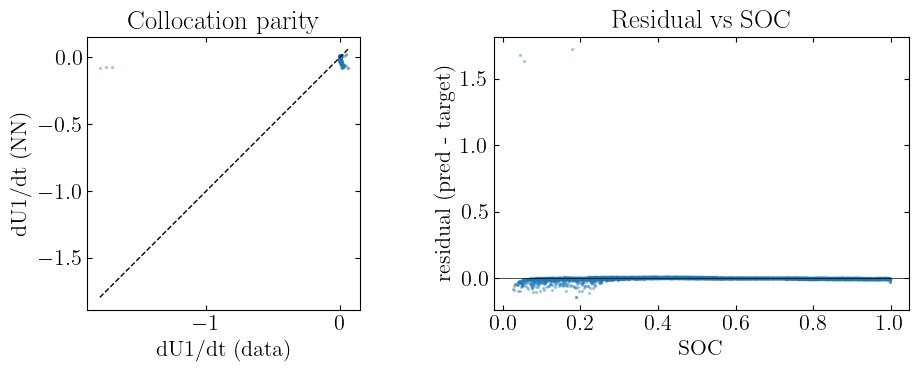

In [31]:
fig = plot_collocation_fit(u1_net, inputs, targets)

plt.plot(col_history['train'])
plot_predictions(model, train_trajs[:3], title_prefix='Train: ')
plot_predictions(model, test_trajs[:3],  title_prefix='Test: ')

In [19]:
# 4. Stage 2: ODE fine-tuning (optional but recommended)
print("\n=== Stage 2: ODE fine-tuning ===")
trajs = prepare_trajectories(data)
split = int(len(trajs) * 0.8)
train_trajs = trajs[:split]
test_trajs  = trajs[split:]

# Lower learning rate for fine-tuning — we're already close
ode_history = train(
    model, train_trajs, test_trajs,
    n_epochs=25,         # fewer epochs needed after pre-training
    lr=1e-4,              # smaller lr to not destroy pre-trained weights
    print_every=10,
)


=== Stage 2: ODE fine-tuning ===
Epoch    1 | train MSE 0.028249 | test MSE 0.000000 | lr 1.0e-04
Epoch   25 | train MSE 0.009180 | test MSE 0.000000 | lr 1.0e-04


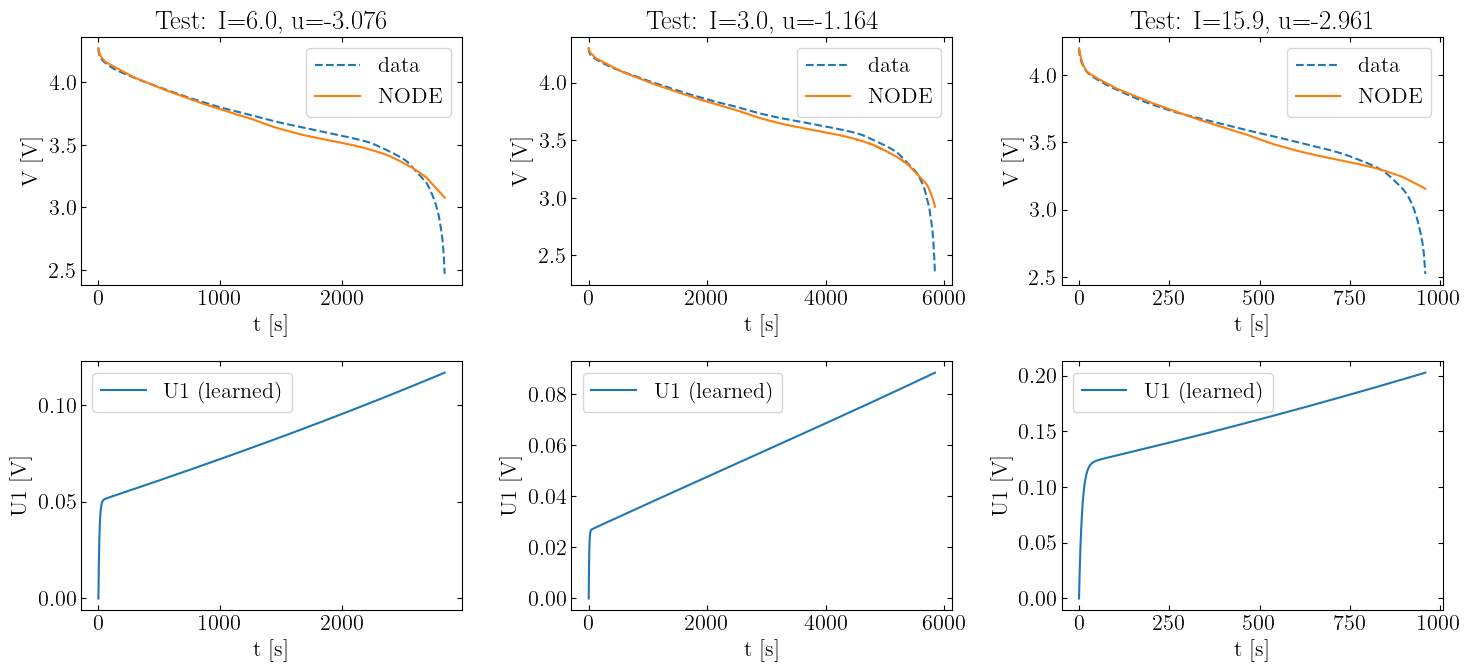

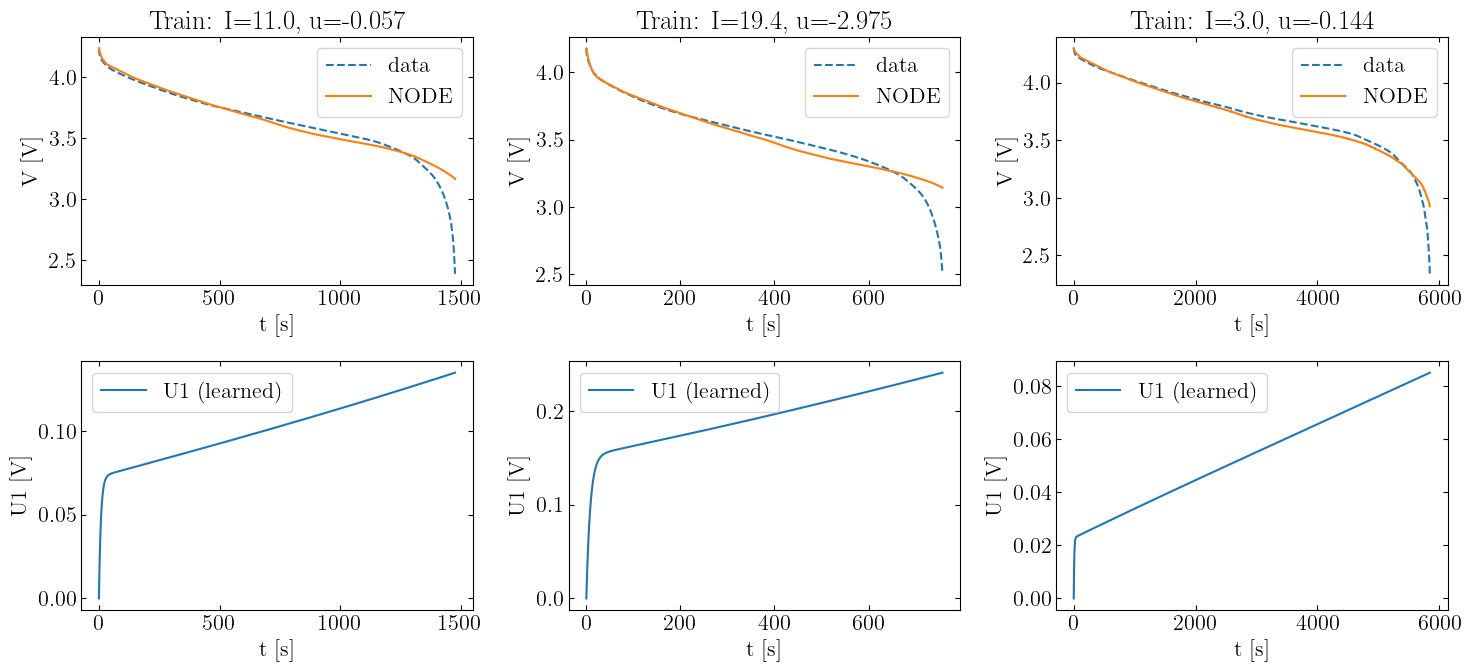

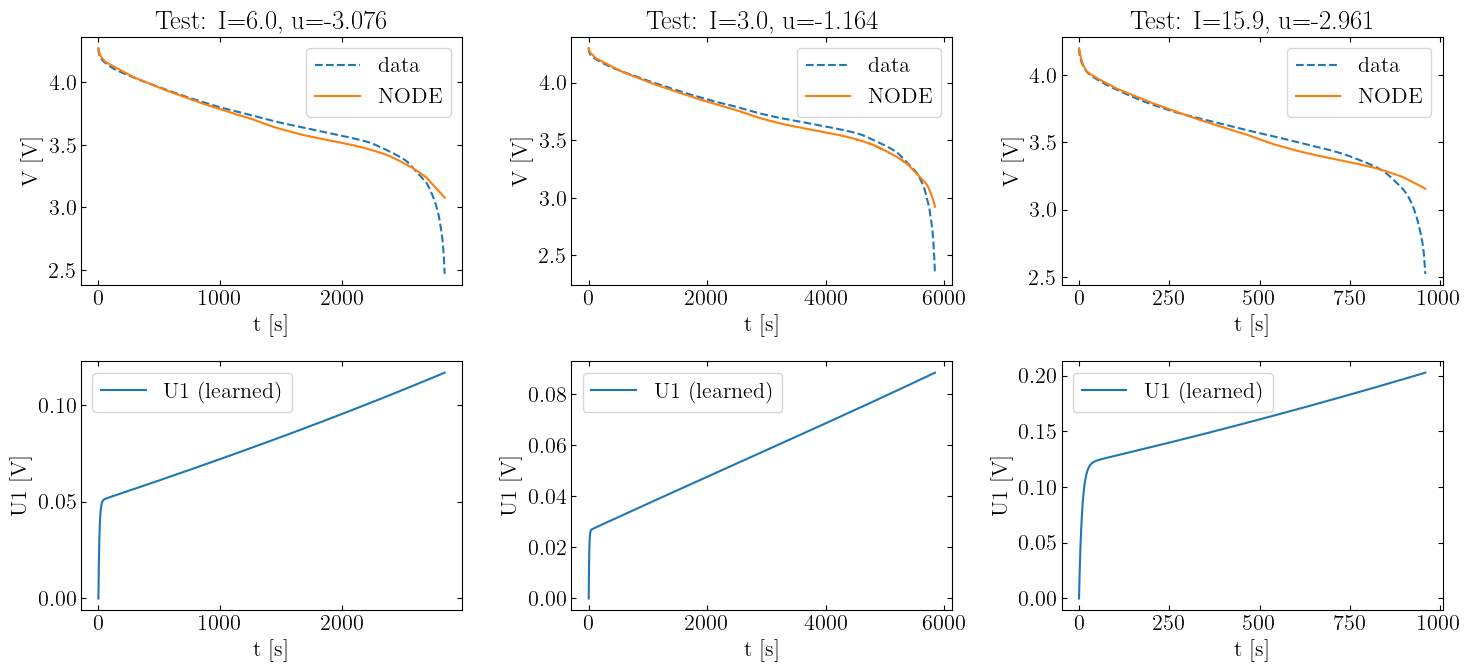

In [35]:
# plot_history(ode_history)

plot_predictions(model, train_trajs[:3], title_prefix='Train: ')
plot_predictions(model, test_trajs[:3],  title_prefix='Test: ')

In [ ]:
save_model = True
if save_model:
    model_name = 'JN_model'
    # check if the file already exists and if so, append a number to the name
    model_number = 1
    save_path = Path(f'multi_models/JN_model_{model_number}.pth')
    if save_path.exists():
        while save_path.exists():
            save_path = Path(f'multi_models/{model_name}_{model_number}.pth')
            model_number += 1
        torch.save(model.state_dict(), f'multi_models/{model_name}_{model_number}.pth')
    else:
        torch.save(model.state_dict(), f'multi_models/{model_name}_{model_number}.pth')
    
    # multi_exp_log.exp_log(model, history, name=f'{model_name}_{model_number}_N{N_trajs}', N_trajs = N_trajs, mse = mse, mae = mae)